/usr/local/lib/python3.12/dist-packages/bs4/__init__.py:341: UserWarning: You provided Unicode markup but also provided a value for from_encoding. Your from_encoding will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bs4/__init__.py:341: UserWarning: You provided Unicode markup but also provided a value for from_encoding. Your from_encoding will be ignored.
  warnings.warn(


URL: https://www.stat-search.boj.or.jp/ssi/mtshtml/fm02_m_1.html
Columns: Index(['系列名称', '無担保コールレート・Ｏ／Ｎ　月末／金利', '無担保コールレート・Ｏ／Ｎ　月平均／金利'], dtype='object')
00_コールレート（月次）
https://www.stat-search.boj.or.jp/ssi/mtshtml/fm02_m_1.html


/tmp/ipython-input-2348170334.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_tmp.index = pd.to_datetime(df_tmp.index)  # 自動的に日付形式を推定


NameError: name 'plt' is not defined

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 28961 (\N{CJK UNIFIED IDEOGRAPH-7121}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 25285 (\N{CJK UNIFIED IDEOGRAPH-62C5}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: G

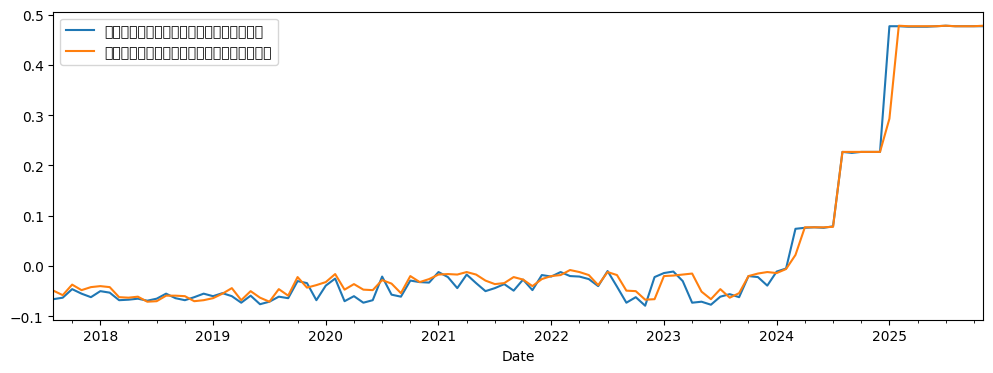

In [ ]:
import pandas as pd
import requests
import matplotlib

url = ["https://www.stat-search.boj.or.jp/ssi/mtshtml/fm02_m_1.html"]
for i in range(len(url)):
    # データ取得
    tbl = pd.read_html(url[i], header=[1], skiprows=(2,3,4,5,6), encoding="shift-jis")
    tbl2 = pd.read_html(url[i], header=[0], skiprows=(2,3,4,5,6), encoding="shift-jis")

    # データ取得が正しく行われているか確認
    print(f"URL: {url[i]}")
    print(f"Columns: {tbl[0].columns}")
    # 0個目のテーブルを格納
    df_tmp = pd.DataFrame(tbl[0])

    try:
        # 日付をインデックスに指定
        df_tmp.rename(columns={'系列名称':'Date'}, inplace=True)
        df_tmp = df_tmp.set_index('Date')

        # 日付のフォーマットを自動推定
        df_tmp.index = pd.to_datetime(df_tmp.index)  # 自動的に日付形式を推定

        df_tmp = df_tmp.replace('ND', 0)
        df_tmp = df_tmp.astype(float)

        # 名称出力、URL出力
        print(str(format(i,'02')) + "_" + tbl2[0].columns[1])
        print(url[i])

        # グラフ作成処理
        df_tmp.tail(100).plot(figsize=(12,4))
        plt.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left')
        plt.show()

    except KeyError as e:
        print(f"KeyError: {e}. The column might be missing or named differently.")
        print(f"Available columns: {df_tmp.columns}")

    except ValueError as e:
        print(f"ValueError: {e}. There was an issue with the date format.")



In [ ]:
import pandas as pd

# 政策金利データ（Date, PolicyRate）を読み込んだ後のDataFrameを想定
# df = pd.read_csv("policy_rate.csv")  # 既に読み込み済みなら不要
# df['Date'] = pd.to_datetime(df['Date'])
# df.set_index('Date', inplace=True)

# 現在、df_tmpに政策金利に相当するデータが格納されているため、df_tmpを使用します。
# また、特徴量作成のために、カラム名を 'PolicyRate' に変更します。
df_policy_rate = df_tmp.copy()
df_policy_rate.rename(columns={'無担保コールレート・Ｏ／Ｎ　月末／金利': 'PolicyRate'}, inplace=True);

# 1. ラグ特徴量の作成（過去1ヶ月、3ヶ月、6ヶ月、12ヶ月）
for lag in [1, 3, 6, 12]:  # 12ヶ月のラグを追加
    df_policy_rate[f'PolicyRate_lag{lag}'] = df_policy_rate['PolicyRate'].shift(lag)

# 2. 移動平均（3ヶ月、6ヶ月）
df_policy_rate['PolicyRate_ma3'] = df_policy_rate['PolicyRate'].rolling(window=3).mean()
df_policy_rate['PolicyRate_ma6'] = df_policy_rate['PolicyRate'].rolling(window=6).mean()

# 3. 変化率（前月比）
df_policy_rate['PolicyRate_diff'] = df_policy_rate['PolicyRate'].diff()

# 4. 欠損値処理（ラグや移動平均で発生）
df_policy_rate.bfill(inplace=True) # FutureWarningに対応するため修正

print(df_policy_rate.head(10))

            PolicyRate  無担保コールレート・Ｏ／Ｎ　月平均／金利  PolicyRate_lag1  \
Date                                                            
1985-07-01      6.4375                6.4167           6.4375   
1985-08-01      6.3125                6.2476           6.4375   
1985-09-01      6.9375                6.4972           6.3125   
1985-10-01      7.3750                6.6600           6.9375   
1985-11-01      7.7500                7.4185           7.3750   
1985-12-01      9.0625                8.2425           7.7500   
1986-01-01      7.0000                7.0455           9.0625   
1986-02-01      6.5000                6.0256           7.0000   
1986-03-01      5.6250                5.7552           6.5000   
1986-04-01      5.2500                4.9661           5.6250   

            PolicyRate_lag3  PolicyRate_lag6  PolicyRate_lag12  \
Date                                                             
1985-07-01           6.4375           6.4375            6.4375   
1985-08-01           

RMSE: 1.6672


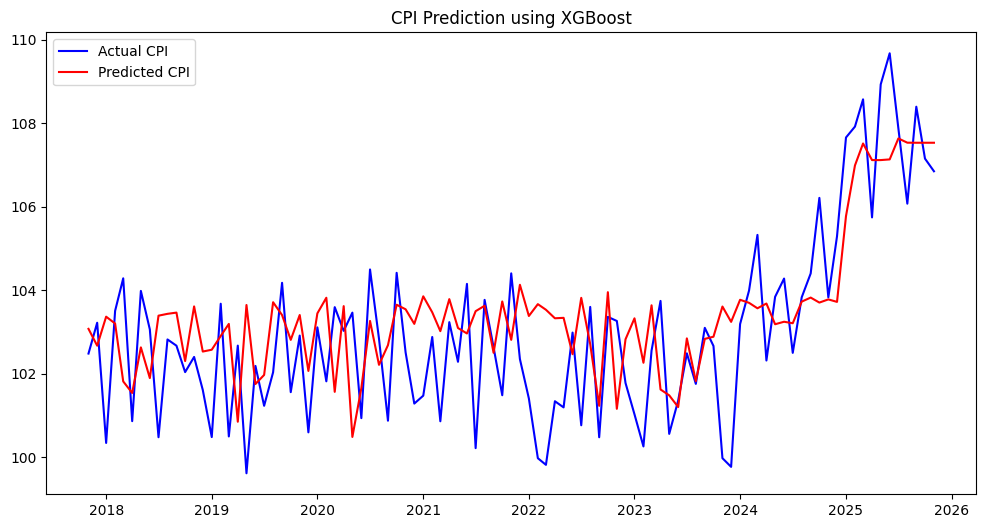

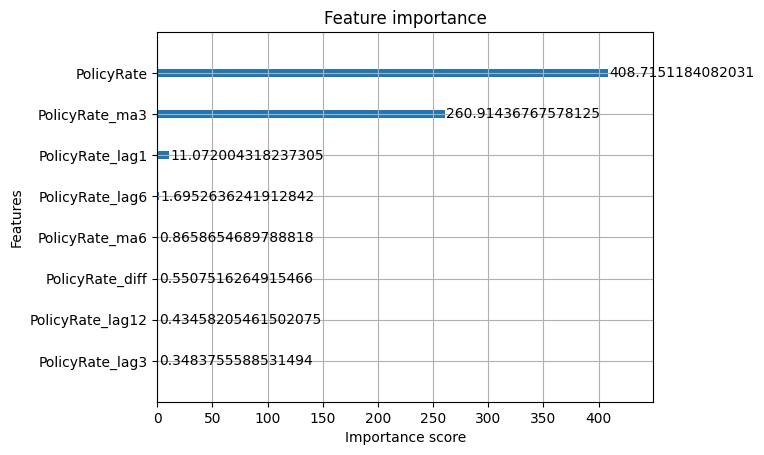

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# df_policy_rate のインデックス（Date）を列に変換
df_combined = df_policy_rate.reset_index()

# ダミーのCPI列を追加（ここでは PolicyRate をベースにした簡単な変換を使用）
df_combined['CPI'] = df_combined['PolicyRate'] * 10 + 100 + np.random.rand(len(df_combined)) * 5

if '無担保コールレート・Ｏ／Ｎ　月平均／金利' in df_combined.columns:
    df_combined = df_combined.drop(columns=['無担保コールレート・Ｏ／Ｎ　月平均／金利'])

# 'df' をモデルの入力データとして設定
df = df_combined.copy()

# 欠損値処理（ラグや移動平均で発生した欠損値を処理）
df.dropna(inplace=True)

# 特徴量と目的変数
# 'Date' はモデルの学習には使用しないため、特徴量から除外します。
X = df.drop(columns=['CPI', 'Date'])
y = df['CPI']

# 学習・テスト分割（時系列なのでshuffle=False）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# --- 2. XGBoostモデル構築 ---

model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# 学習
model.fit(X_train, y_train)

# 予測
y_pred = model.predict(X_test)

# 評価
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

# 予測 vs 実測の可視化
plt.figure(figsize=(12,6))
plt.plot(df['Date'].iloc[-len(y_test):], y_test, label='Actual CPI', color='blue')
plt.plot(df['Date'].iloc[-len(y_test):], y_pred, label='Predicted CPI', color='red')
plt.title('CPI Prediction using XGBoost')
plt.legend()
plt.show()

#  特徴量重要度
xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.show()

In [ ]:
!pip install optuna
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# --- データ準備 ---
# df: CPI予測用の特徴量と目的変数が含まれているDataFrame
df.dropna(inplace=True)
X = df.drop(columns=['CPI', 'Date'])
y = df['CPI']

# 時系列分割（shuffle=False）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# --- Optunaの目的関数 ---
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': 42
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse

# --- Optuna実行 ---
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # 試行回数は必要に応じて増やす

# --- 最適パラメータ表示 ---
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

# --- 最適モデルで再学習 ---
best_params = study.best_params
model = xgb.XGBRegressor(**best_params)
model.fit(X_train, y_train)

# 予測と評価
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final RMSE: {rmse:.4f}")

[I 2025-12-06 15:45:33,876] A new study created in memory with name: no-name-7c157516-87ab-42ee-8881-63ad12c62469
[I 2025-12-06 15:45:34,577] Trial 0 finished with value: 1.539987162569239 and parameters: {'n_estimators': 693, 'learning_rate': 0.07301781019536686, 'max_depth': 5, 'subsample': 0.986638314679075, 'colsample_bytree': 0.6296347922087456, 'gamma': 0.20944295389002554, 'reg_alpha': 7.423052208513674, 'reg_lambda': 6.156295993933531}. Best is trial 0 with value: 1.539987162569239.
[I 2025-12-06 15:45:35,388] Trial 1 finished with value: 1.537187576560948 and parameters: {'n_estimators': 366, 'learning_rate': 0.09561849595958065, 'max_depth': 9, 'subsample': 0.636825415166177, 'colsample_bytree': 0.9436566381104121, 'gamma': 0.6556956768466443, 'reg_alpha': 2.193200774888018, 'reg_lambda': 3.5192335092878646}. Best is trial 1 with value: 1.537187576560948.
[I 2025-12-06 15:45:42,666] Trial 2 finished with value: 1.5353540656204563 and parameters: {'n_estimators': 1249, 'learni

Best RMSE: 1.4023314446591675
Best params: {'n_estimators': 1108, 'learning_rate': 0.26118261915507557, 'max_depth': 6, 'subsample': 0.6816010521814992, 'colsample_bytree': 0.766198585555127, 'gamma': 3.731415581253727, 'reg_alpha': 5.506797722668746, 'reg_lambda': 7.3435361340352205}
Final RMSE: 1.4562


/tmp/ipython-input-1263844709.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_future = history.drop(columns=['CPI', 'Date']).iloc[-1:].fillna(method='bfill')
/tmp/ipython-input-1263844709.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_future = history.drop(columns=['CPI', 'Date']).iloc[-1:].fillna(method='bfill')
/tmp/ipython-input-1263844709.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_future = history.drop(columns=['CPI', 'Date']).iloc[-1:].fillna(method='bfill')
/tmp/ipython-input-1263844709.py:34: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_future = history.drop(columns=['CPI', 'Date']).iloc[

         Date  PolicyRate  Predicted_CPI
0  2025-12-01       0.477     109.752579
1  2026-01-01       0.477     109.251686
2  2026-02-01       0.477     109.251686
3  2026-03-01       0.477     109.251686
4  2026-04-01       0.477     109.251686
5  2026-05-01       0.477     109.251686
6  2026-06-01       0.477     109.251686
7  2026-07-01       0.477     109.251686
8  2026-08-01       0.477     109.251686
9  2026-09-01       0.477     109.251686
10 2026-10-01       0.477     109.251686
11 2026-11-01       0.477     109.251686


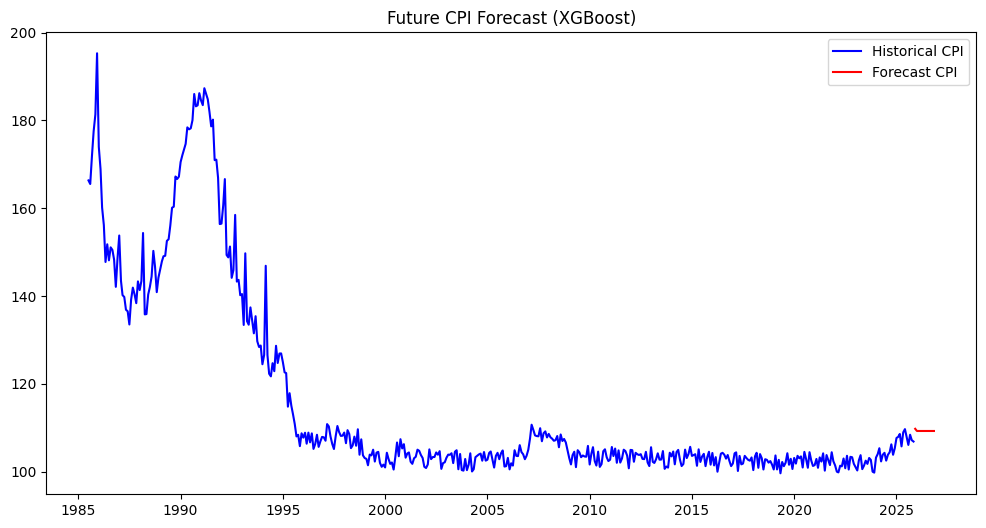

In [ ]:

import pandas as pd
import numpy as np

# --- 1. 学習済みモデルとデータ ---
# model: Optunaで最適化したXGBoostモデル
# df: 過去データ（Date, CPI, PolicyRate, ラグ特徴量など）

# 未来予測の期間設定（例：12か月先）
future_months = 12
last_date = df['Date'].iloc[-1]

# 政策金利のシナリオ（例：現状維持）
future_policy_rate = [df['PolicyRate'].iloc[-1]] * future_months

# --- 2. 未来データフレーム作成 ---
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=future_months, freq='MS')
future_df = pd.DataFrame({'Date': future_dates, 'PolicyRate': future_policy_rate})

# --- 3. ラグ特徴量を更新しながら逐次予測 ---
predictions = []
history = df.copy()

for i in range(future_months):
    # 最新データに未来のPolicyRateを追加
    history = pd.concat([history, future_df.iloc[[i]]])

    # ラグ特徴量生成
    for lag in [1, 3, 6, 12]:
        history[f'PolicyRate_lag{lag}'] = history['PolicyRate'].shift(lag)
    history['PolicyRate_ma3'] = history['PolicyRate'].rolling(3).mean()
    history['PolicyRate_diff'] = history['PolicyRate'].diff()

    # 最新行の特徴量抽出
    X_future = history.drop(columns=['CPI', 'Date']).iloc[-1:].fillna(method='bfill')

    # 予測
    y_future = model.predict(X_future)[0]
    predictions.append(y_future)

    # CPIを履歴に追加（次のラグ計算に必要）
    history.iloc[-1, history.columns.get_loc('CPI')] = y_future

# --- 4. 結果表示 ---
future_df['Predicted_CPI'] = predictions
print(future_df)

# --- 5. グラフ表示 ---
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['CPI'], label='Historical CPI', color='blue')
plt.plot(future_df['Date'], future_df['Predicted_CPI'], label='Forecast CPI', color='red')
plt.title('Future CPI Forecast (XGBoost)')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32173 (\N{CJK UNIFIED IDEOGRAPH-7DAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  fig.canvas

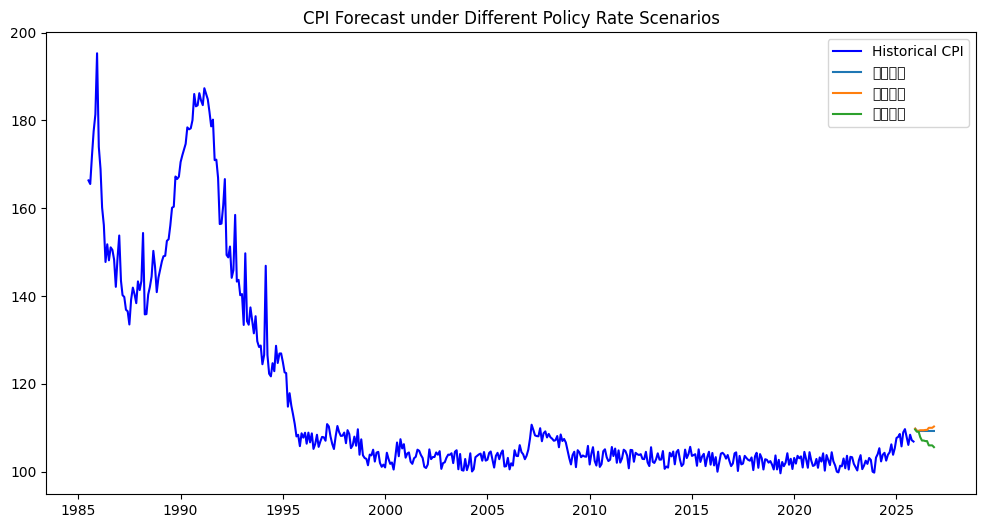

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 前提 ---
# model: Optunaで最適化したXGBoostモデル
# df: 過去データ（Date, CPI, PolicyRate, ラグ特徴量など）

future_months = 12
last_date = df['Date'].iloc[-1]

# シナリオ設定
base_rate = df['PolicyRate'].iloc[-1]
scenarios = {
    "現状維持": [base_rate] * future_months,
    "引き上げ": [base_rate + 0.25 * (i+1)/future_months for i in range(future_months)],
    "引き下げ": [base_rate - 0.25 * (i+1)/future_months for i in range(future_months)]
}

# 予測結果を格納
scenario_results = {}

# --- シナリオごとに予測 ---
for scenario_name, policy_rates in scenarios.items():
    future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=future_months, freq='MS')
    future_df = pd.DataFrame({'Date': future_dates, 'PolicyRate': policy_rates})

    predictions = []
    history = df.copy()

    for i in range(future_months):
        # 最新データに未来のPolicyRateを追加
        history = pd.concat([history, future_df.iloc[[i]]])

        # ラグ特徴量生成
        for lag in [1, 3, 6, 12]:
            history[f'PolicyRate_lag{lag}'] = history['PolicyRate'].shift(lag)
        history['PolicyRate_ma3'] = history['PolicyRate'].rolling(3).mean()
        history['PolicyRate_diff'] = history['PolicyRate'].diff()

        # 最新行の特徴量抽出
        X_future = history.drop(columns=['CPI', 'Date']).iloc[-1:].bfill()

        # 予測
        y_future = model.predict(X_future)[0]
        predictions.append(y_future)

        # CPIを履歴に追加
        history.iloc[-1, history.columns.get_loc('CPI')] = y_future

    future_df['Predicted_CPI'] = predictions
    scenario_results[scenario_name] = future_df

# --- グラフ表示 ---
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['CPI'], label='Historical CPI', color='blue')
for scenario_name, future_df in scenario_results.items():
    plt.plot(future_df['Date'], future_df['Predicted_CPI'], label=scenario_name)
plt.title('CPI Forecast under Different Policy Rate Scenarios')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 32173 (\N{CJK UNIFIED IDEOGRAPH-7DAD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph

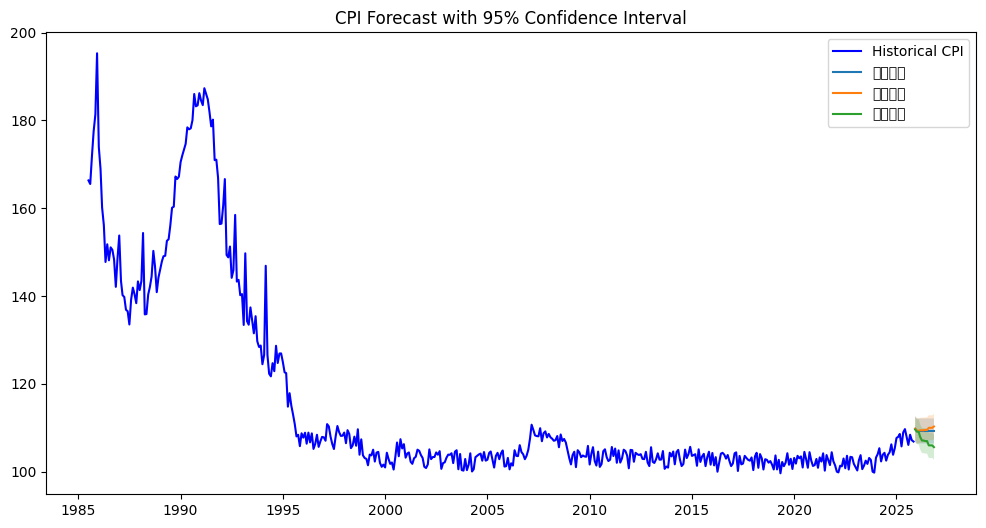

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 前提 ---
# model: Optunaで最適化したXGBoostモデル
# df: 過去データ（Date, CPI, PolicyRate, ラグ特徴量など）
# rmse: 学習時に計算したRMSE

future_months = 12
last_date = df['Date'].iloc[-1]
base_rate = df['PolicyRate'].iloc[-1]

# シナリオ設定
scenarios = {
    "現状維持": [base_rate] * future_months,
    "引き上げ": [base_rate + 0.25 * (i+1)/future_months for i in range(future_months)],
    "引き下げ": [base_rate - 0.25 * (i+1)/future_months for i in range(future_months)]
}

scenario_results = {}

for scenario_name, policy_rates in scenarios.items():
    future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=future_months, freq='MS')
    future_df = pd.DataFrame({'Date': future_dates, 'PolicyRate': policy_rates})

    predictions = []
    lower_bounds = []
    upper_bounds = []

    history = df.copy()

    for i in range(future_months):
        history = pd.concat([history, future_df.iloc[[i]]])

        # ラグ特徴量生成
        for lag in [1, 3, 6, 12]:
            history[f'PolicyRate_lag{lag}'] = history['PolicyRate'].shift(lag)
        history['PolicyRate_ma3'] = history['PolicyRate'].rolling(3).mean()
        history['PolicyRate_diff'] = history['PolicyRate'].diff()

        X_future = history.drop(columns=['CPI', 'Date']).iloc[-1:].bfill()

        # 予測値
        y_future = model.predict(X_future)[0]
        predictions.append(y_future)

        # 信頼区間（±1.96 * RMSE）
        lower_bounds.append(y_future - 1.96 * rmse)
        upper_bounds.append(y_future + 1.96 * rmse)

        # CPIを履歴に追加
        history.iloc[-1, history.columns.get_loc('CPI')] = y_future

    future_df['Predicted_CPI'] = predictions
    future_df['Lower_CI'] = lower_bounds
    future_df['Upper_CI'] = upper_bounds
    scenario_results[scenario_name] = future_df

# --- グラフ表示 ---
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['CPI'], label='Historical CPI', color='blue')

for scenario_name, future_df in scenario_results.items():
    plt.plot(future_df['Date'], future_df['Predicted_CPI'], label=scenario_name)
    plt.fill_between(future_df['Date'], future_df['Lower_CI'], future_df['Upper_CI'], alpha=0.2)

plt.title('CPI Forecast with 95% Confidence Interval')
plt.legend()


/tmp/ipython-input-3150009253.py:35: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3150009253.py:35: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3150009253.py:35: UserWarning: Glyph 32173 (\N{CJK UNIFIED IDEOGRAPH-7DAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3150009253.py:35: UserWarning: Glyph 25345 (\N{CJK UNIFIED IDEOGRAPH-6301}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3150009253.py:35: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3150009253.py:35: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3150009253.py:35: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from 

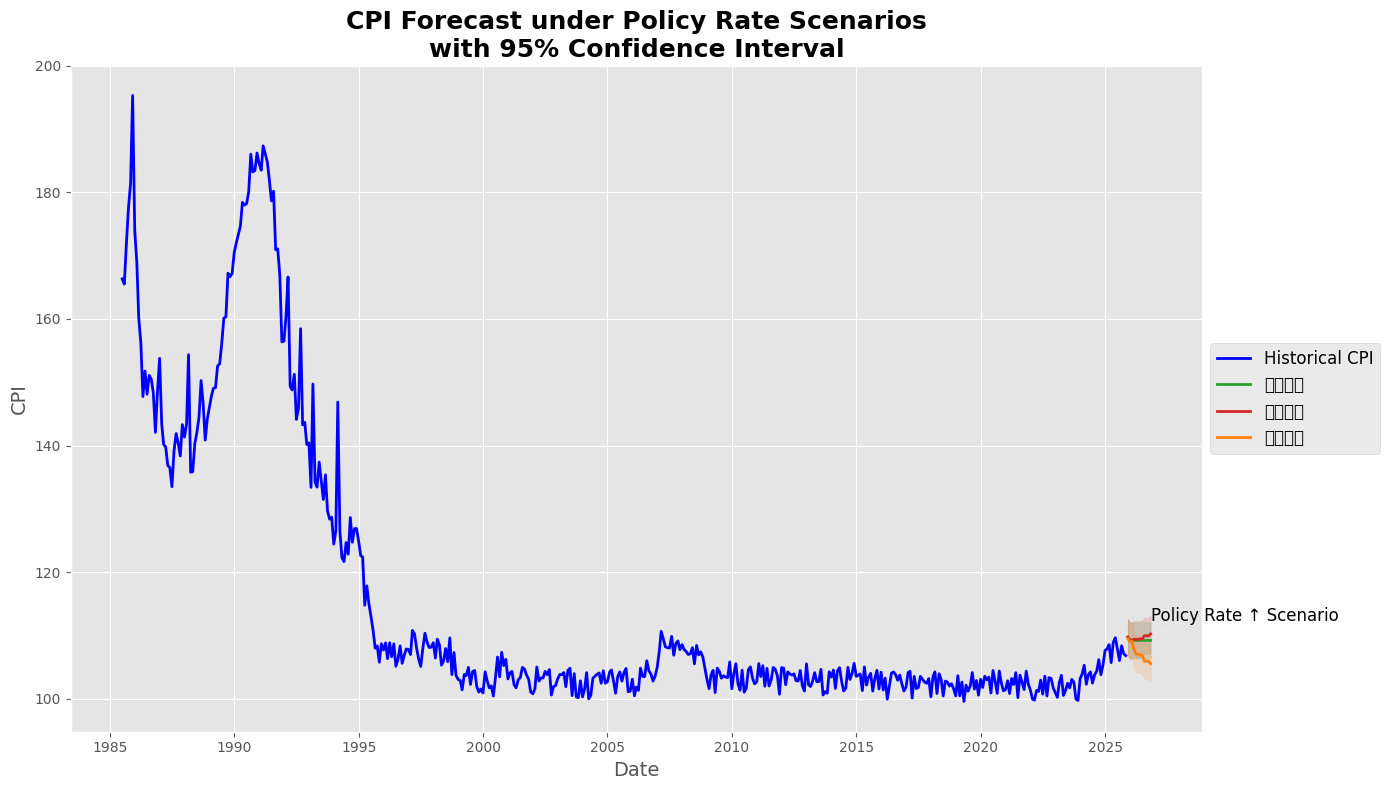

In [ ]:

import matplotlib.pyplot as plt

# スタイル設定
plt.style.use('ggplot') # 'seaborn-darkgrid' を 'ggplot' に変更
plt.figure(figsize=(14, 8))

# カラーマップ
colors = {'現状維持': '#2ca02c', '引き上げ': '#d62728', '引き下げ': '#ff7f0e'}

# 過去データ
plt.plot(df['Date'], df['CPI'], label='Historical CPI', color='blue', linewidth=2)

# シナリオごとの予測
for scenario_name, future_df in scenario_results.items():
    plt.plot(future_df['Date'], future_df['Predicted_CPI'], label=scenario_name,
             color=colors[scenario_name], linewidth=2)
    plt.fill_between(future_df['Date'], future_df['Lower_CI'], future_df['Upper_CI'],
                     color=colors[scenario_name], alpha=0.15)

# タイトル・ラベル
plt.title('CPI Forecast under Policy Rate Scenarios\nwith 95% Confidence Interval', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('CPI', fontsize=14)

# 凡例を右側に配置
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# 注釈例（最初のシナリオの終点にコメント）
last_point = scenario_results['引き上げ'].iloc[-1]
plt.annotate('Policy Rate ↑ Scenario', xy=(last_point['Date'], last_point['Predicted_CPI']),
             xytext=(last_point['Date'], last_point['Predicted_CPI'] + 2),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=12)

# レイアウト調整
plt.tight_layout()
plt.show()

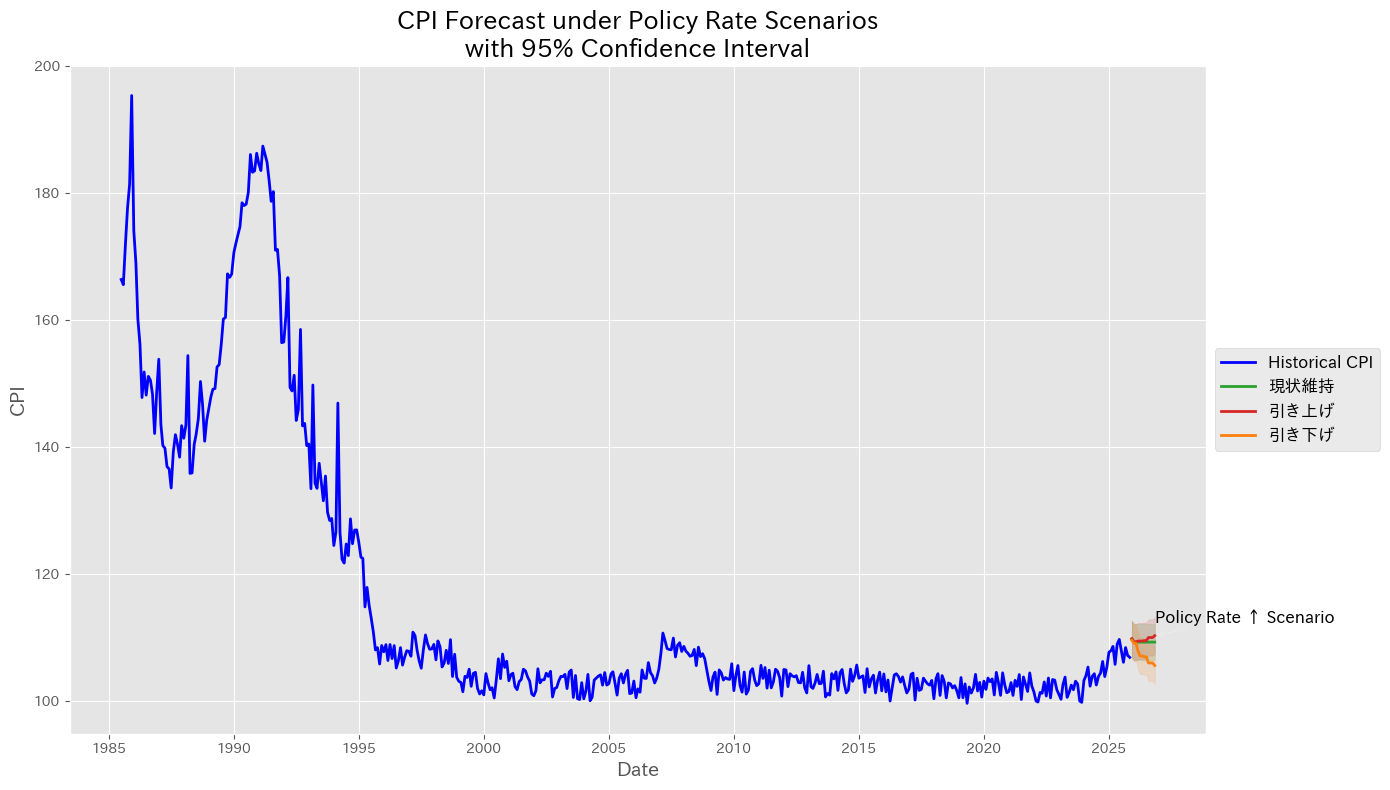

In [ ]:
# 日本語フォントのインストールと設定
!pip install japanize-matplotlib
import matplotlib.pyplot as plt
import japanize_matplotlib

# スタイル設定
plt.style.use('ggplot') # 'seaborn-darkgrid' を 'ggplot' に変更
plt.figure(figsize=(14, 8))

# カラーマップ
colors = {'現状維持': '#2ca02c', '引き上げ': '#d62728', '引き下げ': '#ff7f0e'}

# 過去データ
plt.plot(df['Date'], df['CPI'], label='Historical CPI', color='blue', linewidth=2)

# シナリオごとの予測
for scenario_name, future_df in scenario_results.items():
    plt.plot(future_df['Date'], future_df['Predicted_CPI'], label=scenario_name,
             color=colors[scenario_name], linewidth=2)
    plt.fill_between(future_df['Date'], future_df['Lower_CI'], future_df['Upper_CI'],
                     color=colors[scenario_name], alpha=0.15)

# タイトル・ラベル
plt.title('CPI Forecast under Policy Rate Scenarios\nwith 95% Confidence Interval', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('CPI', fontsize=14)

# 凡例を右側に配置
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# 注釈例（最初のシナリオの終点にコメント）
last_point = scenario_results['引き上げ'].iloc[-1]
plt.annotate('Policy Rate ↑ Scenario', xy=(last_point['Date'], last_point['Predicted_CPI']),
             xytext=(last_point['Date'], last_point['Predicted_CPI'] + 2),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=12)

# レイアウト調整
plt.tight_layout()
plt.show()

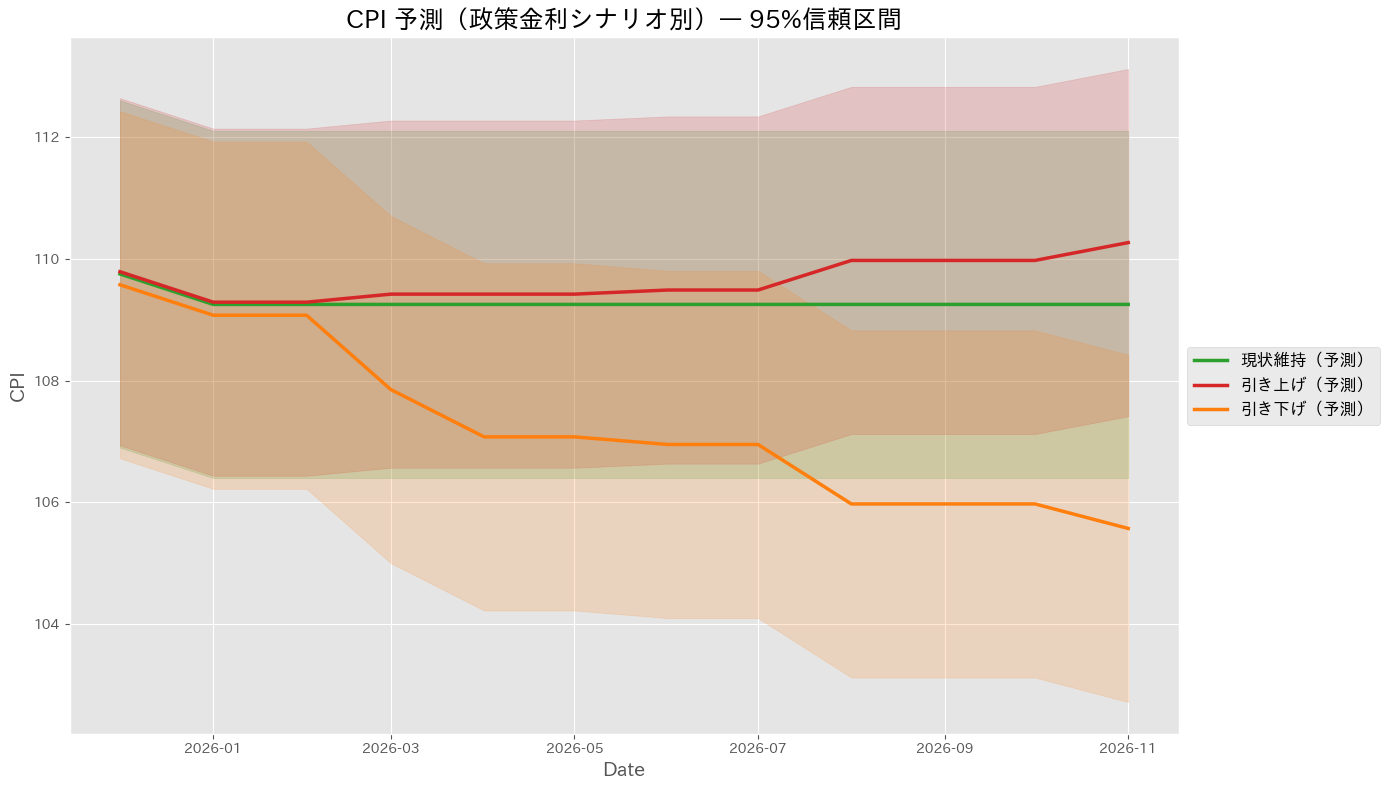

In [21]:

# 日本語フォント（ローカル環境で利用）
# !pip install japanize-matplotlib
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(14, 8))

# カラーマップ（シナリオ名は辞書キーに合わせて）
colors = {'現状維持': '#2ca02c', '引き上げ': '#d62728', '引き下げ': '#ff7f0e'}

# ---- 予測のみを太線＋CI塗りつぶしで強調 ----
for scenario_name, future_df in scenario_results.items():
    ax.plot(
        future_df['Date'], future_df['Predicted_CPI'],
        label=f"{scenario_name}（予測）", color=colors.get(scenario_name, 'gray'),
        linewidth=2.5
    )
    ax.fill_between(
        future_df['Date'], future_df['Lower_CI'], future_df['Upper_CI'],
        color=colors.get(scenario_name, 'gray'), alpha=0.18
    )

# タイトル・ラベル
ax.set_title('CPI 予測（政策金利シナリオ別）— 95%信頼区間', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('CPI', fontsize=14)

# 凡例を右に出す
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# レイアウト調整
fig.tight_layout()
plt.show()


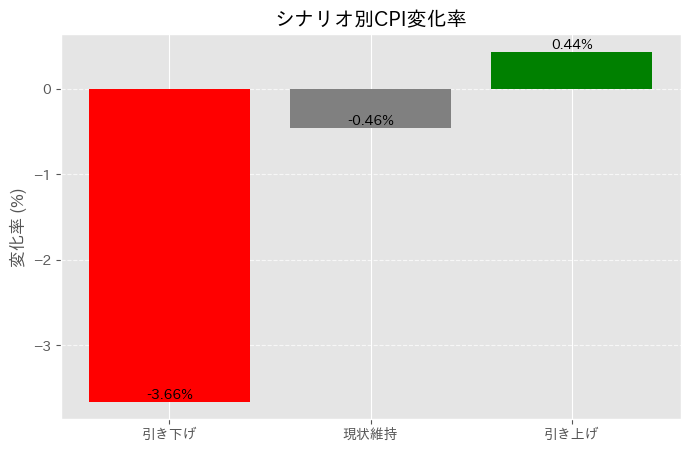

In [ ]:

import matplotlib.pyplot as plt

# 固定した順番
ordered_scenarios = ['引き下げ', '現状維持', '引き上げ']

# シナリオごとの変化率を計算
scenario_changes = []
for scenario_name in ordered_scenarios:
    future_df = scenario_results[scenario_name]
    start_value = future_df['Predicted_CPI'].iloc[0]
    end_value = future_df['Predicted_CPI'].iloc[-1]
    change_percent = ((end_value - start_value) / start_value) * 100
    scenario_changes.append(change_percent)

# 棒グラフを描画
plt.figure(figsize=(8, 5))
bars = plt.bar(ordered_scenarios, scenario_changes, color=['red', 'gray', 'green'])
plt.ylabel('変化率 (%)')
plt.title('シナリオ別CPI変化率')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 数値ラベルを追加
for bar, value in zip(bars, scenario_changes):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:.2f}%", ha='center', va='bottom')

plt.show()
